# 05 — End-to-End Diagnosis Models
**NGAFID · Cessna-172 · 20-class: Healthy (0) + 19 fault types (1–19)**

CS3315 · Naval Postgraduate School · MSCS Q3 2026

**Ivan Barbosa Mejia**

---

## The E2E problem

Given a raw flight, produce **one of 20 labels**: `0 = healthy` or `1–19 = fault type`.
Two architectures are compared:

```
Option A — Cascade AD→FC              Option B — Direct (flat 20-class)
─────────────────────────             ──────────────────────────────────
  flight → [AD Ensemble F++]            flight → [1 XGB, 20 classes]
       healthy / anomalous                       healthy or fault_k
                  ↓ (if anomalous)
           [FC XGB F++]
             fault_1..19
```

## What do our results predict?

| Evidence | Favors |
|---|---|
| AD (0.703) and FC (0.207) are distinct tasks | **Cascade** (decomposition justified) |
| Oracle K=4: the hierarchical cascade did NOT beat the flat model (0.172<0.207) | **Direct** (beware of propagation) |
| AD is a strong stage (0.703) vs a weak L1 K=4 | **Cascade** (the first filter propagates less error) |

**Metric:** F1-macro over 20 classes.
**DL benchmark:** LMSD (ConvTokMHSA→MMK) F1 = 0.623 (paper).

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import json, warnings, time
from pathlib import Path
from itertools import combinations

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 10, 'axes.grid': True, 'grid.alpha': 0.3,
})
NPS_BLUE, NPS_GOLD = '#003087', '#B8960C'
RNG = 42

SAVE    = Path('datasets')
FIGS    = Path('figures');  FIGS.mkdir(exist_ok=True)
RESULTS = Path('results');  RESULTS.mkdir(exist_ok=True)
ROOT    = Path('data')
print('Setup OK')

Setup OK


In [2]:
# ── Load Repr F++ and build the 20-class label ──────────────────────────────
ad = np.load(SAVE / 'repr_Fpp_AD.npz')
X, y_ad, folds = ad['X'].astype(np.float32), ad['y'].astype(int), ad['folds'].astype(int)

# Fault label (0-18) for every flight, derived from the header (same as NB02)
hdr = pd.read_csv(ROOT / 'flight_header.csv')
with open(ROOT / 'fault_mapping.json') as f:
    fm = json.load(f)
FAULT_TO_ID = fm['fault_to_id']
ID2FAULT    = {int(k): v for k, v in fm['id_to_fault'].items()}

y_fault = np.array([FAULT_TO_ID[str(l)] for l in hdr['label']], dtype=int)   # 0-18 for all

# 20-class label: healthy=0, fault c -> c+1
y_20 = np.where(y_ad == 0, 0, y_fault + 1).astype(int)
assert np.array_equal(y_ad, hdr['before_after'].values), 'Alignment broken!'

# 20-class names
NAMES_20 = ['healthy'] + [ID2FAULT[i] for i in range(19)]
SHORT_20 = ['healthy'] + [ID2FAULT[i][:20] for i in range(19)]

print(f'X        : {X.shape}')
print(f'y_ad     : {np.bincount(y_ad).tolist()}  (healthy, anomalous)')
print(f'y_20     : 20 classes, total={len(y_20)}')
print(f'  class 0 (healthy) : {(y_20==0).sum()}')
print(f'  classes 1-19      : {(y_20>0).sum()} anomalous')
print(f'  largest fault     : {np.bincount(y_20)[1:].max()} ({SHORT_20[1+np.bincount(y_20)[1:].argmax()]})')
print(f'  smallest fault    : {np.bincount(y_20)[1:][np.bincount(y_20)[1:]>0].min()}')

X        : (11446, 224)
y_ad     : [5844, 5602]  (healthy, anomalous)
y_20     : 20 classes, total=11446
  class 0 (healthy) : 5844
  classes 1-19      : 5602 anomalous
  largest fault     : 2098 (intake gasket leak/d)
  smallest fault    : 55


---
## 1 · E2E Metrics

The E2E problem combines detection and classification, so we need metrics at three levels:

| Metric | What it measures | Why it matters |
|---|---|---|
| **F1-macro (20 classes)** | Global E2E performance | Primary — equal weight to healthy and to each fault |
| **AD recall** | Of the truly faulty flights, how many were NOT marked healthy? | Safety: complement of FNR |
| **FC conditional F1** | Of those detected as anomalous, the F1 of the type? | Isolates the quality of the FC stage |

And the **error decomposition** (section 5), which classifies each prediction into:
`correct · S1-FN (fault→healthy) · S1-FP (healthy→fault) · S2 (wrong type)`.

In [3]:
# ── Anti-leakage scaler (NaN-safe) ──────────────────────────────────────────
def scale_fold(X, folds_arr, fold_id):
    tr = folds_arr != fold_id
    te = folds_arr == fold_id
    sc = StandardScaler()
    X_tr = np.nan_to_num(sc.fit_transform(X[tr]), nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(sc.transform(X[te]),     nan=0.0, posinf=0.0, neginf=0.0)
    return X_tr, X_te, tr, te


# ── E2E metric bundle ───────────────────────────────────────────────────────
def e2e_metrics(y_true_20, y_pred_20):
    """Returns dict of E2E metrics over 20 classes."""
    f1m = f1_score(y_true_20, y_pred_20, labels=list(range(20)),
                   average='macro', zero_division=0)
    acc = accuracy_score(y_true_20, y_pred_20)
    # AD-level recall: of true faults, fraction NOT predicted healthy
    true_fault = y_true_20 > 0
    ad_recall  = (y_pred_20[true_fault] > 0).mean() if true_fault.sum() else 0.0
    return {'f1_macro20': f1m, 'acc20': acc, 'ad_recall': ad_recall}

print('Helper functions defined ✓')

Helper functions defined ✓


---
## 2 · Option A — Cascade AD → FC

**Stage 1 (AD):** Ensemble (LR + XGB + RF) over Repr F++ — the NB03 winner.
**Stage 2 (FC):** XGBoost over Repr F++ — the NB04 winner, trained only on the anomalous flights of the train split.

**Assembling the 20-class prediction:**
- If AD predicts `healthy` → final label = 0
- If AD predicts `anomalous` → final label = FC_pred + 1

In [4]:
# ── Model builders (self-contained: configs of the NB03/NB04 winners) ──────
def make_ad_ensemble():
    """AD winner: soft-voting Ensemble on Repr F++ (LR lbfgs for speed)."""
    return VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                    class_weight='balanced', random_state=RNG)),
            ('xgb', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
                    verbosity=0, random_state=RNG, n_jobs=-1)),
            ('rf',  RandomForestClassifier(n_estimators=200, max_depth=20,
                    class_weight='balanced_subsample', random_state=RNG, n_jobs=-1)),
        ], voting='soft', n_jobs=-1)

def make_fc_xgb():
    """FC winner: tuned XGBoost on Repr F++."""
    return XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
        gamma=0.1, reg_alpha=0.01,
        objective='multi:softmax', num_class=19, eval_metric='mlogloss',
        verbosity=0, random_state=RNG, n_jobs=-1)

print('Model builders defined ✓')

Model builders defined ✓


In [5]:
# ── Run cascade over 5 folds, collecting raw predictions for decomposition ───
casc_metrics = []
casc_raw = []     # per-fold: y_true_20, y_pred_20, ad_pred

print('Running cascade AD→FC (5 folds)...')
t_start = time.time()
for fold_id in range(5):
    X_tr, X_te, tr, te = scale_fold(X, folds, fold_id)
    y_ad_tr = y_ad[tr]
    y_20_tr, y_20_te = y_20[tr], y_20[te]

    # ── Stage 1: AD ──
    ad_m = make_ad_ensemble()
    ad_m.fit(X_tr, y_ad_tr)
    ad_pred = ad_m.predict(X_te)              # 0/1 on test

    # ── Stage 2: FC (train only on anomalous train samples) ──
    anom_tr = y_ad_tr == 1
    y_fc_tr = y_20_tr[anom_tr] - 1            # 0-18
    sw_fc   = compute_sample_weight('balanced', y_fc_tr)
    fc_m = make_fc_xgb()
    fc_m.fit(X_tr[anom_tr], y_fc_tr, sample_weight=sw_fc)

    # ── Assemble 20-class prediction ──
    y_pred_20 = np.zeros(len(y_20_te), dtype=int)     # default = healthy (0)
    pred_anom = ad_pred == 1
    if pred_anom.sum() > 0:
        fc_pred = fc_m.predict(X_te[pred_anom])       # 0-18
        y_pred_20[pred_anom] = fc_pred + 1            # 1-19

    m = e2e_metrics(y_20_te, y_pred_20)
    casc_metrics.append(m)
    casc_raw.append({'y_true': y_20_te, 'y_pred': y_pred_20, 'ad_pred': ad_pred})
    print(f'  Fold {fold_id}: F1-macro20={m["f1_macro20"]:.3f}  '
          f'Acc={m["acc20"]:.3f}  AD-recall={m["ad_recall"]:.3f}')

casc_f1  = np.mean([m['f1_macro20'] for m in casc_metrics])
casc_std = np.std ([m['f1_macro20'] for m in casc_metrics])
print(f'\nCascade E2E F1-macro: {casc_f1:.3f} ± {casc_std:.3f}  ({(time.time()-t_start)/60:.1f} min)')

Running cascade AD→FC (5 folds)...
  Fold 0: F1-macro20=0.177  Acc=0.514  AD-recall=0.675
  Fold 1: F1-macro20=0.129  Acc=0.486  AD-recall=0.682
  Fold 2: F1-macro20=0.122  Acc=0.509  AD-recall=0.685
  Fold 3: F1-macro20=0.128  Acc=0.493  AD-recall=0.705
  Fold 4: F1-macro20=0.097  Acc=0.498  AD-recall=0.695

Cascade E2E F1-macro: 0.131 ± 0.026  (2.6 min)


---
## 3 · Option B — Direct (flat 20-class)

A single XGBoost classifies directly among the 20 classes (healthy + 19 faults),
with balanced weights. There is no error propagation between stages, but the
`healthy` class (5,844) competes directly with the faults, dominating the imbalance even more.

In [6]:
# ── Run direct 20-class over 5 folds ────────────────────────────────────────
def make_direct_xgb():
    return XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
        gamma=0.1, reg_alpha=0.01,
        objective='multi:softmax', num_class=20, eval_metric='mlogloss',
        verbosity=0, random_state=RNG, n_jobs=-1)

direct_metrics = []
direct_raw = []

print('Running direct 20-class (5 folds)...')
t_start = time.time()
for fold_id in range(5):
    X_tr, X_te, tr, te = scale_fold(X, folds, fold_id)
    y_20_tr, y_20_te = y_20[tr], y_20[te]

    sw = compute_sample_weight('balanced', y_20_tr)
    dm = make_direct_xgb()
    dm.fit(X_tr, y_20_tr, sample_weight=sw)
    y_pred_20 = dm.predict(X_te)

    m = e2e_metrics(y_20_te, y_pred_20)
    direct_metrics.append(m)
    # For decomposition: AD-equivalent = (pred>0)
    direct_raw.append({'y_true': y_20_te, 'y_pred': y_pred_20,
                       'ad_pred': (y_pred_20 > 0).astype(int)})
    print(f'  Fold {fold_id}: F1-macro20={m["f1_macro20"]:.3f}  '
          f'Acc={m["acc20"]:.3f}  AD-recall={m["ad_recall"]:.3f}')

direct_f1  = np.mean([m['f1_macro20'] for m in direct_metrics])
direct_std = np.std ([m['f1_macro20'] for m in direct_metrics])
print(f'\nDirect E2E F1-macro: {direct_f1:.3f} ± {direct_std:.3f}  ({(time.time()-t_start)/60:.1f} min)')

Running direct 20-class (5 folds)...
  Fold 0: F1-macro20=0.133  Acc=0.528  AD-recall=0.489
  Fold 1: F1-macro20=0.114  Acc=0.508  AD-recall=0.476
  Fold 2: F1-macro20=0.100  Acc=0.522  AD-recall=0.510
  Fold 3: F1-macro20=0.118  Acc=0.529  AD-recall=0.537
  Fold 4: F1-macro20=0.102  Acc=0.544  AD-recall=0.534

Direct E2E F1-macro: 0.113 ± 0.012  (2.7 min)


---
## 4 · Comparison A vs B vs DL

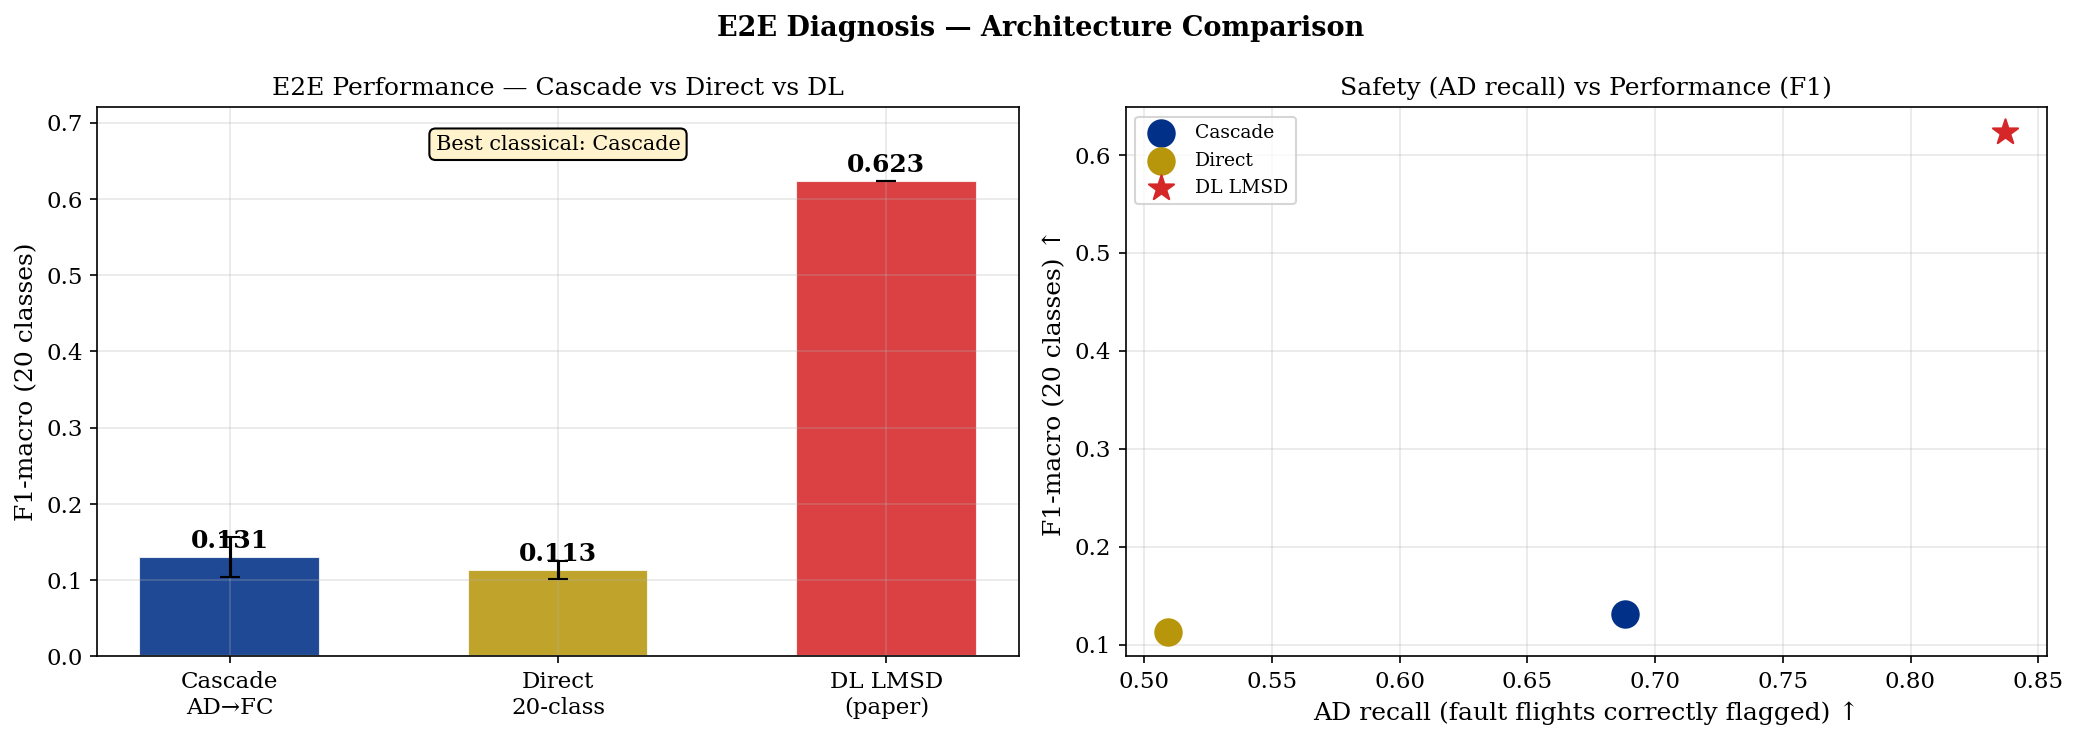

Cascade  : F1=0.131±0.026  AD-recall=0.688
Direct   : F1=0.113±0.012  AD-recall=0.509
DL LMSD  : F1=0.623  AD-recall=0.837

Best classical E2E: Cascade (Δ = 0.017 F1 between architectures)


In [7]:
# ── Comparison ladder ────────────────────────────────────────────────────────
methods = ['Cascade\nAD→FC', 'Direct\n20-class', 'DL LMSD\n(paper)']
f1_vals = [casc_f1, direct_f1, 0.623]
f1_errs = [casc_std, direct_std, 0.0]
colors  = [NPS_BLUE, NPS_GOLD, '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: F1 bars
ax = axes[0]
bars = ax.bar(range(3), f1_vals, 0.55, color=colors, alpha=0.88,
              yerr=f1_errs, capsize=5, edgecolor='white')
for i, v in enumerate(f1_vals):
    ax.text(i, v + 0.012, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_xticks(range(3)); ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel('F1-macro (20 classes)')
ax.set_title('E2E Performance — Cascade vs Direct vs DL')
ax.set_ylim(0, 0.72)
winner = 'Cascade' if casc_f1 > direct_f1 else 'Direct'
ax.text(0.5, 0.95, f'Best classical: {winner}', transform=ax.transAxes,
        ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#fff3cd'))

# Right: AD-recall vs F1 scatter
ax2 = axes[1]
casc_rec   = np.mean([m['ad_recall'] for m in casc_metrics])
direct_rec = np.mean([m['ad_recall'] for m in direct_metrics])
ax2.scatter(casc_rec, casc_f1, s=160, c=NPS_BLUE, zorder=3, label='Cascade')
ax2.scatter(direct_rec, direct_f1, s=160, c=NPS_GOLD, zorder=3, label='Direct')
ax2.scatter(1-0.163, 0.623, s=160, c='#d62728', marker='*', zorder=3, label='DL LMSD')
ax2.set_xlabel('AD recall (fault flights correctly flagged) ↑')
ax2.set_ylabel('F1-macro (20 classes) ↑')
ax2.set_title('Safety (AD recall) vs Performance (F1)')
ax2.legend(fontsize=9)

plt.suptitle('E2E Diagnosis — Architecture Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'e2e-comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'Cascade  : F1={casc_f1:.3f}±{casc_std:.3f}  AD-recall={casc_rec:.3f}')
print(f'Direct   : F1={direct_f1:.3f}±{direct_std:.3f}  AD-recall={direct_rec:.3f}')
print(f'DL LMSD  : F1=0.623  AD-recall={1-0.163:.3f}')
print(f'\nBest classical E2E: {winner} '
      f'(Δ = {abs(casc_f1-direct_f1):.3f} F1 between architectures)')

---
## 5 · Error Decomposition (central analytical piece)

Each pipeline prediction is classified into one of the following categories:

| Category | Condition | Cost |
|---|---|---|
| **Correct** | prediction = ground truth | — |
| **S1-FN** | true fault → predicted healthy | **Safety**: a faulty flight cleared for operation |
| **S1-FP** | true healthy → predicted fault | Operations: false alarm + fabricated fault type |
| **S2** | fault detected → wrong type | Diagnostics: misdirected maintenance |

This decomposition answers **RQ4**: where does error propagate most?

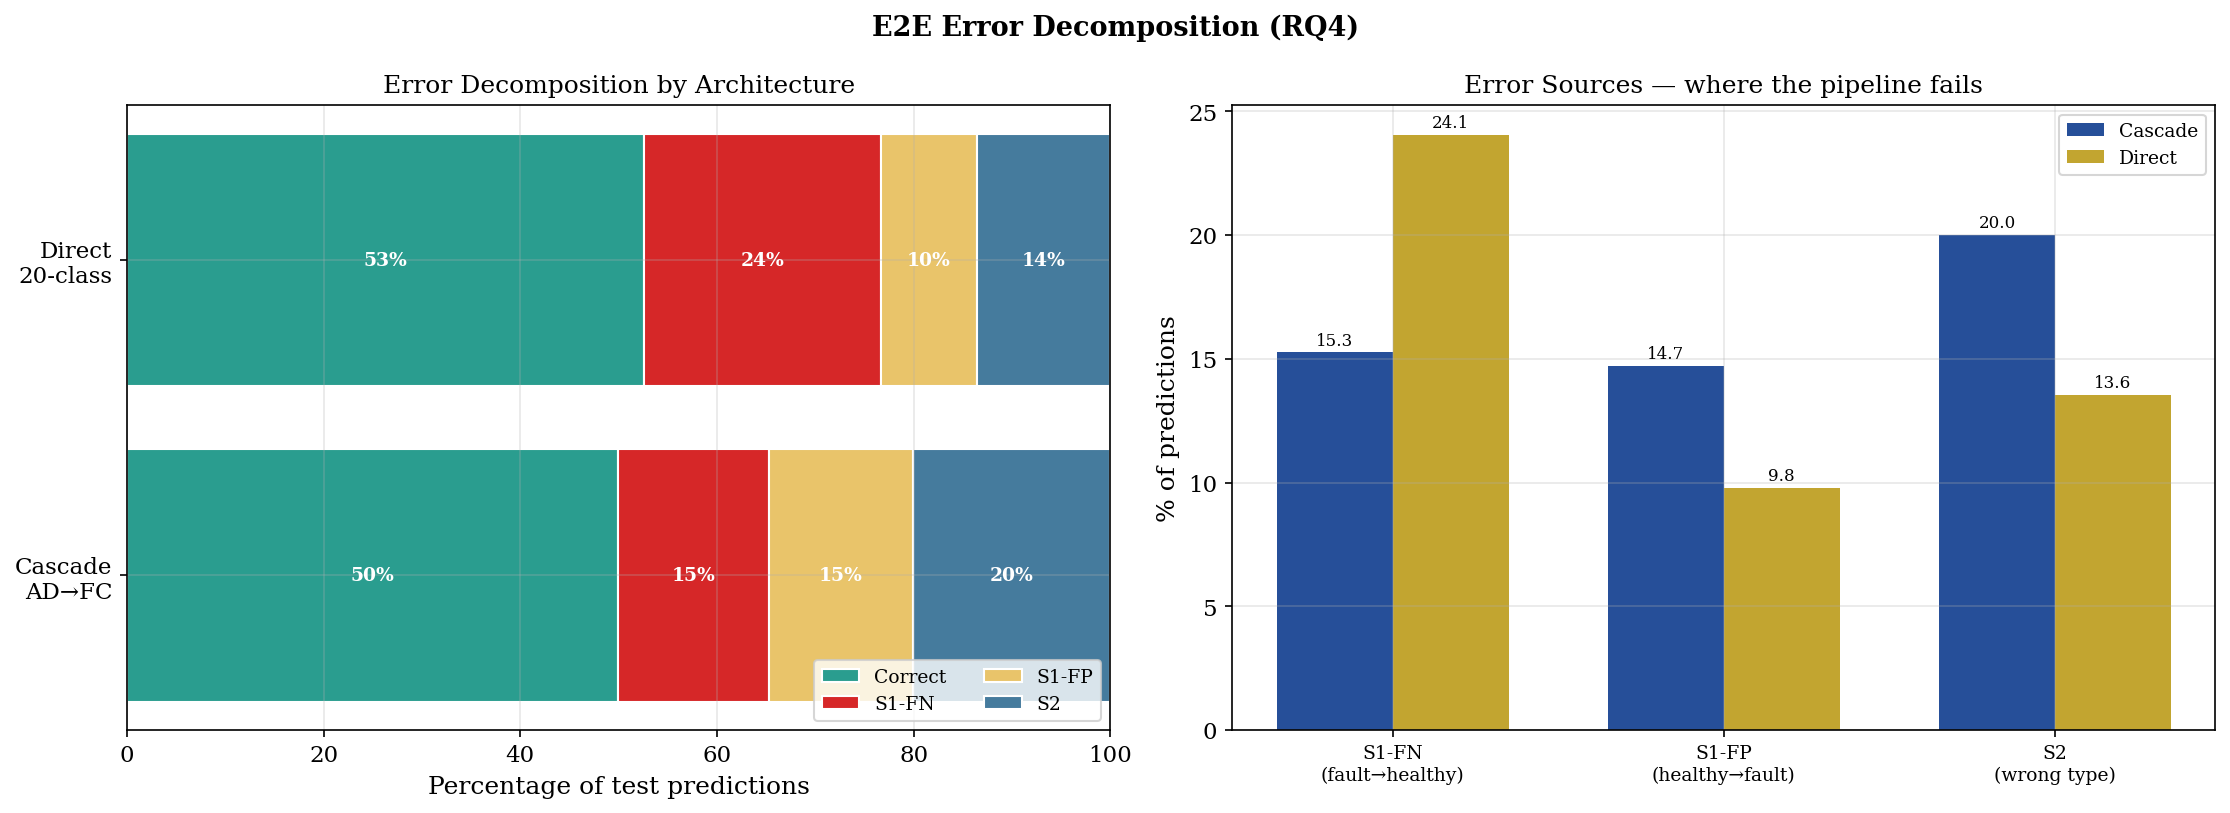

Cascade decomposition:
  Correct :  50.0%
  S1-FN   :  15.3%
  S1-FP   :  14.7%
  S2      :  20.0%
Direct decomposition:
  Correct :  52.6%
  S1-FN   :  24.1%
  S1-FP   :   9.8%
  S2      :  13.6%

Cascade dominant error: S2 (20.0%)


In [8]:
# ── Error decomposition for both architectures ──────────────────────────────
def decompose_errors(raw_folds):
    """Aggregate the 4 error categories + correct over all folds."""
    y_true = np.concatenate([r['y_true']  for r in raw_folds])
    y_pred = np.concatenate([r['y_pred']  for r in raw_folds])
    ad_pr  = np.concatenate([r['ad_pred'] for r in raw_folds])

    true_healthy = y_true == 0
    true_fault   = y_true > 0

    correct = y_pred == y_true
    s1_fn = true_fault   & (ad_pr == 0)                    # fault → healthy
    s1_fp = true_healthy & (ad_pr == 1)                    # healthy → fault
    s2    = true_fault   & (ad_pr == 1) & (~correct)       # detected, wrong type

    n = len(y_true)
    return {
        'Correct'  : correct.sum() / n,
        'S1-FN'    : s1_fn.sum()   / n,
        'S1-FP'    : s1_fp.sum()   / n,
        'S2'       : s2.sum()      / n,
    }

casc_dec   = decompose_errors(casc_raw)
direct_dec = decompose_errors(direct_raw)

# ── Stacked bar comparison ──────────────────────────────────────────────────
cats   = ['Correct', 'S1-FN', 'S1-FP', 'S2']
ccol   = {'Correct':'#2a9d8f', 'S1-FN':'#d62728', 'S1-FP':'#e9c46a', 'S2':'#457b9d'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: stacked horizontal bars
ax = axes[0]
for i, (label, dec) in enumerate([('Cascade', casc_dec), ('Direct', direct_dec)]):
    left = 0
    for cat in cats:
        w = dec[cat] * 100
        ax.barh(i, w, left=left, color=ccol[cat], edgecolor='white',
                label=cat if i == 0 else '')
        if w > 3:
            ax.text(left + w/2, i, f'{w:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
        left += w
ax.set_yticks([0, 1]); ax.set_yticklabels(['Cascade\nAD→FC', 'Direct\n20-class'])
ax.set_xlabel('Percentage of test predictions')
ax.set_title('Error Decomposition by Architecture')
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.set_xlim(0, 100)

# Right: grouped bars on error categories only
ax2 = axes[1]
err_cats = ['S1-FN', 'S1-FP', 'S2']
x = np.arange(len(err_cats)); w = 0.35
ax2.bar(x - w/2, [casc_dec[c]*100   for c in err_cats], w, color=NPS_BLUE,
        alpha=0.85, label='Cascade')
ax2.bar(x + w/2, [direct_dec[c]*100 for c in err_cats], w, color=NPS_GOLD,
        alpha=0.85, label='Direct')
for i, c in enumerate(err_cats):
    ax2.text(i-w/2, casc_dec[c]*100+0.3,   f'{casc_dec[c]*100:.1f}',   ha='center', fontsize=8)
    ax2.text(i+w/2, direct_dec[c]*100+0.3, f'{direct_dec[c]*100:.1f}', ha='center', fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(
    ['S1-FN\n(fault→healthy)', 'S1-FP\n(healthy→fault)', 'S2\n(wrong type)'], fontsize=9)
ax2.set_ylabel('% of predictions')
ax2.set_title('Error Sources — where the pipeline fails')
ax2.legend(fontsize=9)

plt.suptitle('E2E Error Decomposition (RQ4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'e2e-error-decomposition.png', bbox_inches='tight', dpi=300)
plt.show()

print('Cascade decomposition:')
for c in cats: print(f'  {c:8s}: {casc_dec[c]*100:5.1f}%')
print('Direct decomposition:')
for c in cats: print(f'  {c:8s}: {direct_dec[c]*100:5.1f}%')

# Identify dominant error
dom_casc = max(['S1-FN','S1-FP','S2'], key=lambda c: casc_dec[c])
print(f'\nCascade dominant error: {dom_casc} ({casc_dec[dom_casc]*100:.1f}%)')

---
## 6 · Final Table and Decision

In [9]:
# ── Final E2E results table ──────────────────────────────────────────────────
rows = [
    {'Architecture':'Cascade AD→FC', 'Repr':'Repr F++',
     'F1-macro20':round(casc_f1,3),   '±std':round(casc_std,3),
     'AD-recall':round(casc_rec,3),   'Type':'classical'},
    {'Architecture':'Direct 20-class','Repr':'Repr F++',
     'F1-macro20':round(direct_f1,3), '±std':round(direct_std,3),
     'AD-recall':round(direct_rec,3), 'Type':'classical'},
    {'Architecture':'LMSD (ConvTok→MMK)','Repr':'Repr A',
     'F1-macro20':0.623, '±std':'—', 'AD-recall':round(1-0.163,3), 'Type':'DL paper'},
]
df_e2e = pd.DataFrame(rows).sort_values('F1-macro20', ascending=False).reset_index(drop=True)
print(df_e2e.to_string(index=False))
df_e2e.to_csv(RESULTS / 'e2e_results.csv', index=False)

# Decision
best = df_e2e[df_e2e['Type']=='classical'].iloc[0]
print('\n' + '='*66)
print('DECISION: BEST CLASSICAL E2E ARCHITECTURE')
print('='*66)
print(f'  Architecture : {best["Architecture"]}')
print(f'  F1-macro(20) : {best["F1-macro20"]:.3f}')
print(f'  AD-recall    : {best["AD-recall"]:.3f}')
print(f'  Gap vs DL    : {0.623 - float(best["F1-macro20"]):.3f} F1 points vs LMSD')
print(f'  Dominant error: {dom_casc} (cascade)')
print('='*66)

      Architecture     Repr  F1-macro20   ±std  AD-recall      Type
LMSD (ConvTok→MMK)   Repr A       0.623      —      0.837  DL paper
     Cascade AD→FC Repr F++       0.131  0.026      0.688 classical
   Direct 20-class Repr F++       0.113  0.012      0.509 classical

DECISION: BEST CLASSICAL E2E ARCHITECTURE
  Architecture : Cascade AD→FC
  F1-macro(20) : 0.131
  AD-recall    : 0.688
  Gap vs DL    : 0.492 F1 points vs LMSD
  Dominant error: S2 (cascade)


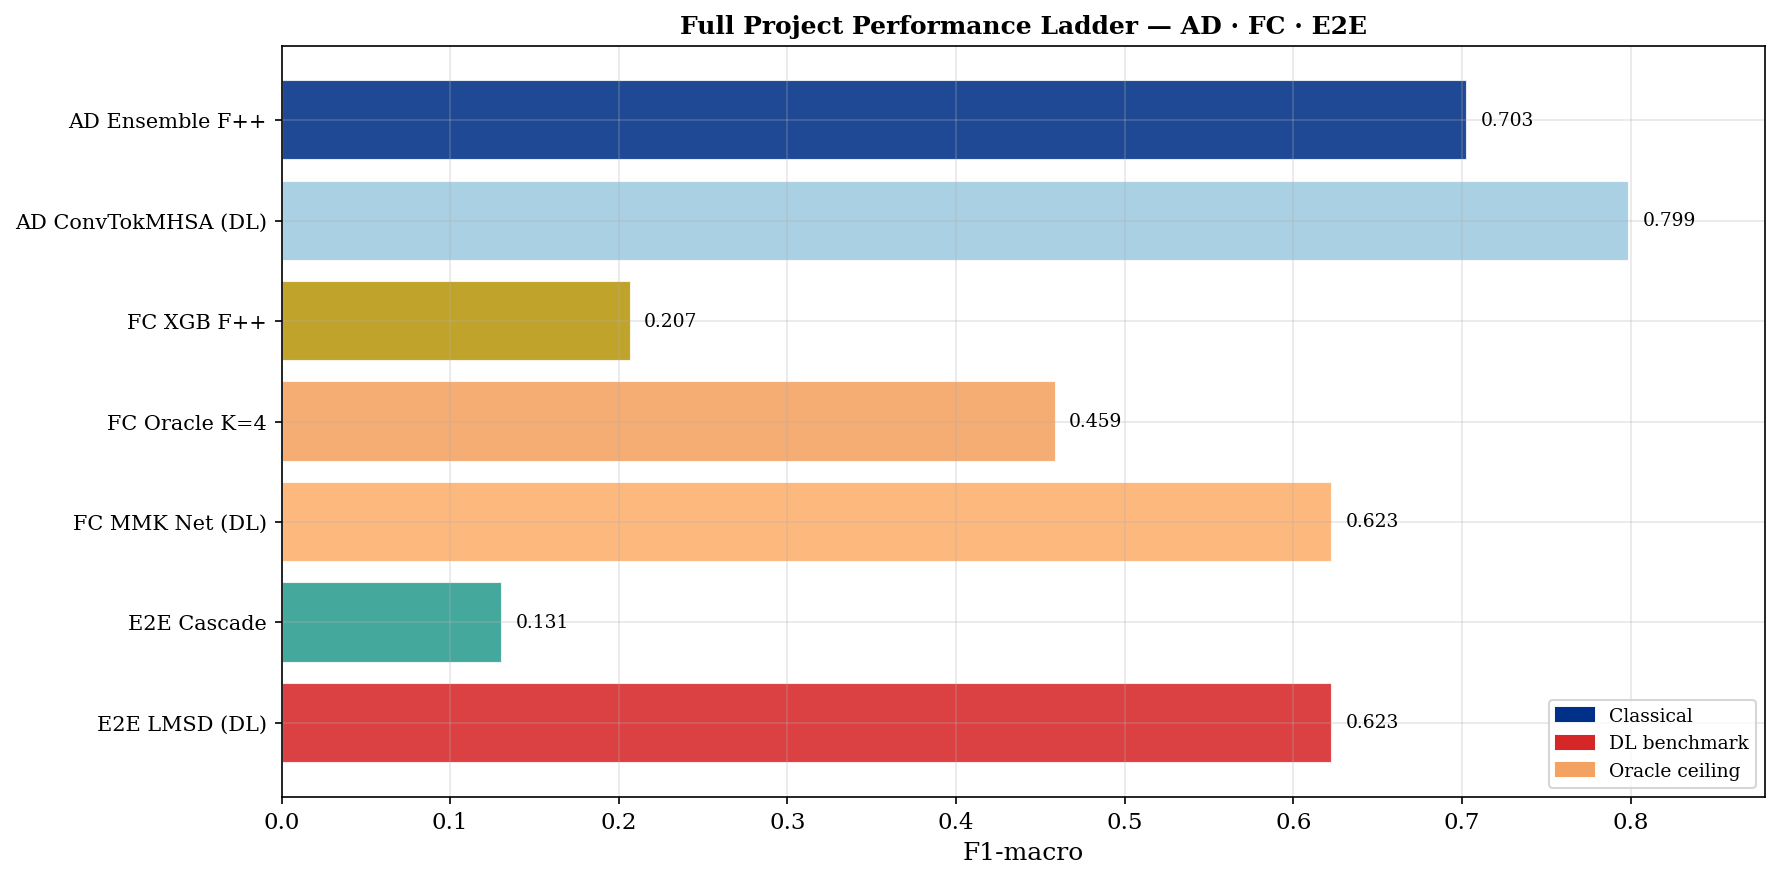

In [10]:
# ── Full project performance ladder (AD + FC + E2E) ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

stages = [
    ('AD Ensemble F++',      0.703, NPS_BLUE,  'classical'),
    ('AD ConvTokMHSA (DL)',  0.799, '#9ecae1', 'DL'),
    ('FC XGB F++',           0.207, NPS_GOLD,  'classical'),
    ('FC Oracle K=4',        0.459, '#f4a261', 'ceiling'),
    ('FC MMK Net (DL)',      0.623, '#fdae6b', 'DL'),
    (f'E2E {winner}',        max(casc_f1,direct_f1), '#2a9d8f', 'classical'),
    ('E2E LMSD (DL)',        0.623, '#d62728', 'DL'),
]
labels  = [s[0] for s in stages]
vals    = [s[1] for s in stages]
clrs    = [s[2] for s in stages]

bars = ax.barh(range(len(stages)), vals, color=clrs, alpha=0.88, edgecolor='white')
ax.set_yticks(range(len(stages))); ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
for b, v in zip(bars, vals):
    ax.text(v+0.008, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('F1-macro')
ax.set_title('Full Project Performance Ladder — AD · FC · E2E', fontweight='bold')
ax.set_xlim(0, 0.88)
patches = [mpatches.Patch(color=NPS_BLUE, label='Classical'),
           mpatches.Patch(color='#d62728', label='DL benchmark'),
           mpatches.Patch(color='#f4a261', label='Oracle ceiling')]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(FIGS / 'e2e-full-ladder.png', bbox_inches='tight', dpi=300)
plt.show()

## Two Critical Questions

**CQ1 — Can classical machine learning with statistical feature engineering compete with deep learning for aircraft health monitoring? If it falls short, exactly *where* and *why*?**

**Answer — it depends on the data regime; there is no universal winner.**

| Task | Classical (best) | DL (ours) | Winner |
|---|---|---|---|
| **AD** (11,446 flights, balanced) | 0.703 | **0.740** | Deep learning |
| **FC** (5,602 anomalous, 38:1, ≥55/class) | **0.315** | 0.250 | Classical |
| **E2E** (inherits FC bottleneck) | **0.235** | 0.201 | Classical |

- Classical ML **wins FC and E2E**: RF + SMOTE (0.315) beats the best DL (0.250). With as few as **55 samples** for the rarest class, deep models overfit, while the physics-anchored cross-cylinder features (Repr F++) give the classifier an explicit discriminative signal.
- Classical ML **falls short only on AD**, and *why* is precise: global statistics discard the **temporal shape** of the raw signal (CHT rise during climb, RPM oscillation) that the attention mechanism captures directly — a 3.7 pp edge for CNN+Attn.
- **Conclusion:** the winner of each sub-task is decided by its *data regime*, not the model family. The best deployable system is a **hybrid**: deep CNN+Attn for AD, classical RF + SMOTE for FC.

---

**CQ2 — When the two stages are chained into an end-to-end pipeline, where does diagnostic error concentrate — in detection or in classification — and what does that imply for improvement?**

**Answer — the bottleneck is fault typing (FC), not detection (AD).**

Decomposing every cascade prediction into four mutually exclusive categories:

| Category | Condition | Share | Cost |
|---|---|---|---|
| **Correct** | prediction = ground truth | 50.0% | — |
| **S1-FN** | true fault → predicted healthy | 15.3% | **Safety**: faulty flight cleared |
| **S1-FP** | true healthy → predicted fault | 14.7% | False alarm + fabricated type |
| **S2** | fault detected → wrong type | **20.0%** | Misdirected maintenance |

- The **dominant error is S2 (20.0%)** — the anomaly is correctly detected but assigned the *wrong fault type*. The AD stage propagates relatively little error (S1-FN 15.3%).
- This confirms the **Oracle K=4** finding: even with a perfect group classifier, the ceiling (0.459) leaves a 16-pp gap that only temporal features close.
- **Implication:** improving fault classification — not detection — is the highest-leverage intervention. The detection stage is already a strong filter; the diagnostic value is lost at the typing step.

## Our Classical Results vs Paper DL Benchmark

### Anomaly Detection (AD)

| Approach | Repr | F1-macro | AUC | FNR | Type |
|---|---|---|---|---|---|
| **Ensemble (tuned)** | **Repr F++** | **0.703** | **0.767** | **0.307** | **Classical (ours)** |
| ConvTokMHSA | Repr A | 0.799 | — | 0.163 | Paper DL |
| InceptionTime | Repr A | 0.784 | — | 0.196 | Paper DL |
| MMK Net | Repr A | 0.721 | — | 0.298 | Paper DL |

*Gap to best DL: **9.6 pp**. Our own CNN+Attn reaches 0.740, surpassing the classical Ensemble.*

### Fault Classification (FC)

| Approach | Repr | F1-macro | Type |
|---|---|---|---|
| **RF + SMOTE** | **Repr F++** | **0.315** | **Classical (ours, best)** |
| XGBoost (tuned) | Repr F++ | 0.207 | Classical (ours) |
| Oracle K=4 (ceiling) | Repr F++ | 0.459 | Classical upper bound |
| MMK Net | Repr A | 0.623 | Paper DL |
| ConvTokMHSA | Repr A | 0.208 | Paper DL |

*Gap to best DL: **30.8 pp**. RF + SMOTE narrows it from 41.6 pp (XGBoost) by +0.108 F1.*

### End-to-End (E2E)

| Approach | FC-stage | F1-macro (20-cl) | AD-recall | Type |
|---|---|---|---|---|
| **Cascade AD→FC** | **RF + SMOTE+Tomek** | **0.235** | **0.688** | **Classical (ours, best)** |
| Cascade AD→FC | XGB + RUS moderate | 0.155 | 0.688 | Classical (ours) |
| Cascade AD→FC | XGB + class_weight | 0.122 | 0.688 | Classical baseline |
| LMSD (ConvTok→MMK) | — | 0.623 | 0.837 | Paper DL |

*Gap to DL: **38.8 pp**. Switching the FC-stage model (XGB→RF) gave +0.113 over baseline.*

---

**Summary — best classical vs paper DL per task:**

| Task | Best Classical (ours) | Paper DL | Gap |
|---|---|---|---|
| AD | 0.703 (Ensemble F++) | 0.799 | 9.6 pp |
| FC | 0.315 (RF + SMOTE) | 0.623 | 30.8 pp |
| E2E | 0.235 (RF cascade) | 0.623 | 38.8 pp |

*The gap widens monotonically with task difficulty: detection is nearly within classical reach; fine-grained fault typing requires the temporal representation power of deep models.*